# E-Commerce Data Analytics

## Project Overview

This project analyzes e-commerce order data to identify sales trends,
top-performing categories, customer preferences, and key business insights.

### Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

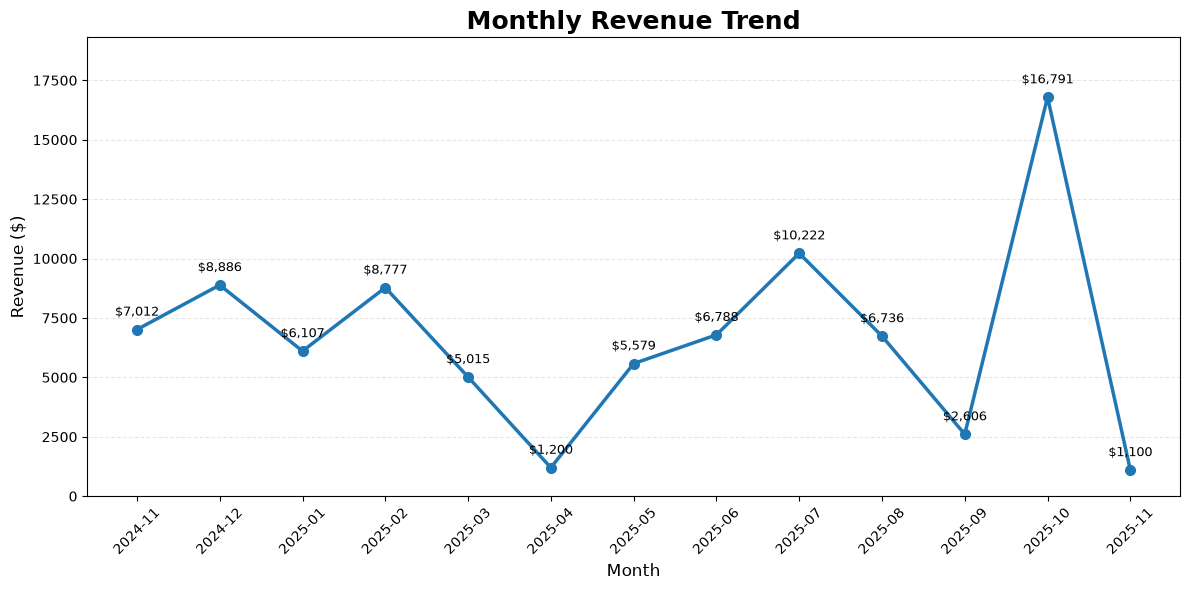

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',None)
pd.set_option('display.width',None)
df = pd.read_excel("../data/ecommerce_orders.xlsx")

df.columns = df.columns.str.strip().str.lower()
text_cols = ["customer_name", "order_id", "product", "category", "payment_method", "status"]

for i in text_cols:
    df[i] = df[i].astype(str).str.strip()
    df[i] = df[i].replace("nan", np.nan)
    df[i] = df[i].str.title()
#print (df)

df["order_date"] = pd.to_datetime(df["order_date"],errors='coerce')
#print(df["order_date"])

df["quantity"] = pd.to_numeric(df["quantity"],errors='coerce').astype("Int64")
#print(df["quantity"])

df["price"]=pd.to_numeric(df["price"],errors='coerce')
#print(df["price"])

df['price'] = df.groupby("product")["price"].transform(lambda x :x.fillna(x.median()) )
#print(df["price"])

df["price"] = df["price"].fillna(df["price"].median())

df = df.dropna(subset=['order_date','quantity'])
#print(df)

dup_order_id = df[df.duplicated(subset=["order_id"],keep=False)]
#print(dup_order_id)

df["total"] = (df["quantity"] * df["price"]).round(2)
#print(df)

df["order_year"] = df["order_date"].dt.year
#print(df["order_year"])

df["order_month"] = df["order_date"].dt.to_period("M")
#print(df["order_month"])

df["uorder_date"] = df["order_date"].dt.date
#print(df["uorder_date"])


valid_orders = df[~df['status'].isin(['Cancelled', 'Returned'])]
#print(valid_orders)

cat_rev = valid_orders.groupby("category").agg(revenue=("total","sum"), items=("quantity","sum")).sort_values("revenue",ascending=False).reset_index()

prod_rev = valid_orders.groupby("product").agg(revenue=("total","sum"), items=("quantity","sum")).sort_values("revenue",ascending=False).head(5)

monthly_rev = valid_orders.groupby("order_month").agg(month_rev=("total","sum")).sort_values("order_month")

daily_rev = valid_orders.groupby("uorder_date").agg(day_rev=("total","sum")).sort_values("uorder_date")
#print(daily_rev)

pm = df["payment_method"].value_counts().reset_index()
#print(pm)

st= df["status"].value_counts(normalize= False)
#print(st)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_rev.index.astype(str),
    monthly_rev["month_rev"],
    marker="o",
    linewidth=2.5,
    markersize=7 )

plt.title("Monthly Revenue Trend", fontsize=18, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.ylim(0, monthly_rev["month_rev"].max() * 1.15)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for x, y in zip(monthly_rev.index.astype(str), monthly_rev["month_rev"]):
    plt.annotate(
        f"${y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9   )
plt.tight_layout()
plt.show()

## Insight

Revenue fluctuated significantly throughout the analyzed period. 
October recorded the highest monthly revenue at approximately $16,791,
while April recorded the lowest at approximately $1,200.
This indicates a highly variable sales pattern, with October showing a
strong peak in business performance.